New Notebook Created by Jupyter MCP Server

In [1]:
from pathlib import Path
import sys, os, json, inspect, nbformat
from datetime import datetime, timezone
from dataclasses import asdict
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
from ai_data_scientist import project_manager as pm, lifecycle, language_router
PROJECT = 'kaggle-v020-kaggle-exp-40-world-happiness'
RUN_ID = 'v020-exp-40'
handle = pm.resolve_project(PROJECT)
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
print({'language': language_router.detect_language('幸福度と所得、健康、社会的支援などの関係と地域差を日本語で分析'), 'notebook': str(handle.notebook_path), 'lifecycle': asdict(lifecycle.get_run_status(RUN_ID))})
print('Kaggle SDK仕様確認（認証情報は表示しない）')
from kaggle.api.kaggle_api_extended import KaggleApi
for name in ['dataset_list', 'dataset_list_files', 'dataset_download_file']:
    print(name, inspect.signature(getattr(KaggleApi, name)))

{'language': 'ja', 'notebook': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-40-world-happiness/notebooks/kaggle-v020-kaggle-exp-40-world-happiness.ipynb', 'lifecycle': {'run_id': 'v020-exp-40', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-40-world-happiness/notebooks/kaggle-v020-kaggle-exp-40-world-happiness.ipynb', 'reason': None}}
Kaggle SDK仕様確認（認証情報は表示しない）
dataset_list (self, sort_by: Optional[str] = None, size: Optional[str] = None, file_type: Optional[str] = None, license_name: Optional[str] = None, tag_ids: Optional[str] = None, search: Optional[str] = None, user: Optional[str] = None, mine: Optional[bool] = False, page: Optional[int] = 1, max_size: Optional[str] = None, min_size: Optional[str] = None) -> list[kagglesdk.datasets.types.dataset_api_service.ApiDataset | None] | None
dataset_list_files (self, 

In [2]:
import contextlib, io
lifecycle.mark_execution_start(RUN_ID)
try:
    api = KaggleApi()
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.authenticate()
        candidates = api.dataset_list(search='world happiness report', sort_by='hottest', page=1)
    search_results = [{'slug': d.ref, 'title': d.title} for d in (candidates or [])]
    display(search_results)
    acquisition_status = 'search_success'
except Exception as exc:
    acquisition_status = 'kaggle_failed'
    acquisition_error = {'stage':'authenticate_or_search', 'exception_type':type(exc).__name__, 'message':'認証情報漏洩防止のため生例外は記録しない。Kaggle検索を取得できなかった。'}
    display(acquisition_error)
    paper_path = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
    if paper_path.exists():
        paper = paper_path.read_text(encoding='utf-8')
        lines = paper.splitlines()
        for i, line in enumerate(lines):
            if 'happiness' in line.lower() or '幸福' in line:
                print('\n'.join(lines[max(0,i-3):i+5]))
    else:
        print('指定white-paper.mdは存在しない。フォールバック不可。')
finally:
    lifecycle.mark_execution_end(RUN_ID)

[{'slug': 'unsdsn/world-happiness', 'title': 'World Happiness Report'},
 {'slug': 'ajaypalsinghlo/world-happiness-report-2021',
  'title': 'World Happiness Report 2021'},
 {'slug': 'PromptCloudHQ/world-happiness-report-2019',
  'title': 'World Happiness Report 2019'},
 {'slug': 'mathurinache/world-happiness-report',
  'title': 'World Happiness Report up to 2022'},
 {'slug': 'jainaru/world-happiness-report-2024-yearly-updated',
  'title': 'World Happiness Report- 2024 '},
 {'slug': 'ajaypalsinghlo/world-happiness-report-2023',
  'title': 'World Happiness Report 2023'},
 {'slug': 'ajaypalsinghlo/world-happiness-report-2022',
  'title': 'world happiness report 2022'},
 {'slug': 'khushikyad001/world-happiness-report',
  'title': 'World Happiness Report'},
 {'slug': 'mathurinache/world-happiness-report-2021',
  'title': 'World Happiness Report 2021'},
 {'slug': 'usamabuttar/world-happiness-report-2005-present',
  'title': 'World Happiness Report, 2005-Present'},
 {'slug': 'mathurinache/worl

In [3]:
lifecycle.mark_execution_start(RUN_ID)
try:
    inspected_datasets = {}
    for slug in ['unsdsn/world-happiness', 'ajaypalsinghlo/world-happiness-report-2021']:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            listing = api.dataset_list_files(slug, page_size=100)
        files = getattr(listing, 'files', getattr(listing, 'dataset_files', []))
        inspected_datasets[slug] = [{'name': f.name, 'bytes': getattr(f, 'total_bytes', None)} for f in files]
    display(inspected_datasets)
except Exception as exc:
    lifecycle.mark_failed(RUN_ID)
    print({'stage':'dataset_list_files', 'exception_type':type(exc).__name__})
    raise RuntimeError('Kaggleファイル一覧取得に失敗。秘密保護のため生例外を抑制。') from None
finally:
    lifecycle.mark_execution_end(RUN_ID)

{'unsdsn/world-happiness': [{'name': '2015.csv', 'bytes': 16557},
  {'name': '2016.csv', 'bytes': 17132},
  {'name': '2017.csv', 'bytes': 29536},
  {'name': '2018.csv', 'bytes': 8809},
  {'name': '2019.csv', 'bytes': 8822}],
 'ajaypalsinghlo/world-happiness-report-2021': [{'name': 'world-happiness-report-2021.csv',
   'bytes': 21687},
  {'name': 'world-happiness-report.csv', 'bytes': 137100}]}

In [5]:
import hashlib, zipfile
import pandas as pd, numpy as np
DATASET_SLUG = 'ajaypalsinghlo/world-happiness-report-2021'
SELECTED_FILES = ['world-happiness-report-2021.csv', 'world-happiness-report.csv']
lifecycle.mark_execution_start(RUN_ID)
try:
    provenance = []
    for filename in SELECTED_FILES:
        if lifecycle.is_cancel_requested(RUN_ID):
            raise RuntimeError('取消要求を検出')
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(DATASET_SLUG, filename, path=str(data_dir), force=True, quiet=True)
        destination = data_dir / filename
        archive = data_dir / (filename + '.zip')
        if not destination.exists() and archive.exists():
            with zipfile.ZipFile(archive) as z:
                members = [m for m in z.namelist() if Path(m).name == filename]
                if len(members) != 1:
                    raise ValueError('CSVアーカイブ内容が一意に確認できない')
                destination.write_bytes(z.read(members[0]))
        if not destination.exists():
            raise FileNotFoundError('Kaggle SDKがCSVを保存しなかった')
        provenance.append({'owner_dataset_slug': DATASET_SLUG, 'filename':filename,
            'retrieved_at_utc': datetime.now(timezone.utc).isoformat(),
            'sha256':hashlib.sha256(destination.read_bytes()).hexdigest(), 'bytes':destination.stat().st_size})
    from ai_data_scientist import ingestion
    cross_ingest = ingestion.ingest(ingestion.SourceSpec('csv', str(data_dir / SELECTED_FILES[0])), row_limit=10000)
    panel_ingest = ingestion.ingest(ingestion.SourceSpec('csv', str(data_dir / SELECTED_FILES[1])), row_limit=10000)
    cross, panel = cross_ingest.dataframe, panel_ingest.dataframe
    print('取込み', {'cross_rows':cross_ingest.row_count,'panel_rows':panel_ingest.row_count,'truncated':cross_ingest.truncated or panel_ingest.truncated})
    print(json.dumps(provenance, ensure_ascii=False, indent=2))
    print('2021地域・順位表', cross.shape, cross.columns.tolist())
    display(cross.head(3))
    print('国年パネル', panel.shape, panel.columns.tolist())
    display(panel.head(3))
    print('国年範囲', panel['year'].min(), panel['year'].max())
    acquisition_status = 'download_success'
    print('取得成功。SDKのdataset_viewは本バージョンに存在せず使用しない。')
except Exception as exc:
    lifecycle.mark_failed(RUN_ID)
    print({'stage':'download_or_read', 'exception_type':type(exc).__name__})
    raise RuntimeError('データ取得・読込に失敗。生例外は表示しない。') from None
finally:
    lifecycle.mark_execution_end(RUN_ID)

[
  {
    "owner_dataset_slug": "ajaypalsinghlo/world-happiness-report-2021",
    "filename": "world-happiness-report-2021.csv",
    "retrieved_at_utc": "2026-10-01T22:25:15.937556+00:00",
    "sha256": "ba2e8711ec2f393c4901f027204cd8c0e23245c9346c1e83fa748912cfebd526",
    "bytes": 21687
  },
  {
    "owner_dataset_slug": "ajaypalsinghlo/world-happiness-report-2021",
    "filename": "world-happiness-report.csv",
    "retrieved_at_utc": "2026-10-01T22:25:17.036235+00:00",
    "sha256": "a92e8067c7dc481655f1bd5e0e0ef8c3c5480fd13a80581382f965eea8b2b75c",
    "bytes": 137100
  }
]
2021地域・順位表 (149, 20) ['Country name', 'Regional indicator', 'Ladder score', 'Standard error of ladder score', 'upperwhisker', 'lowerwhisker', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption', 'Ladder score in Dystopia', 'Explained by: Log GDP per capita', 'Explained by: Social support', 'Explained by: Healthy life expe

,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.0,0.949,-0.098,0.186,2.43,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.7,0.946,0.030,0.179,2.43,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.4,0.919,0.025,0.292,2.43,1.566,1.079,0.816,0.653,0.204,0.413,2.839


,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.370,0.451,50.8,0.718,0.168,0.882,0.518,0.258
1,Afghanistan,2009,4.402,7.540,0.552,51.2,0.679,0.190,0.850,0.584,0.237
2,Afghanistan,2010,4.758,7.647,0.539,51.6,0.600,0.121,0.707,0.618,0.275


In [6]:
lifecycle.register_run(RUN_ID, handle.notebook_path)
print('Kaggle固有の復旧記録: 存在しないSDKメソッドdataset_viewの参照を削除し、CSV取得成功を確認。Jupytermindの不具合ではない。')
print('metadataメソッド', [(name, str(inspect.signature(getattr(api, name)))) for name in ['dataset_metadata', 'dataset_metadata_download'] if hasattr(api, name)])
print('候補メタデータ', [(d.ref, getattr(d, 'license_name', None)) for d in candidates if d.ref == DATASET_SLUG])

Kaggle固有の復旧記録: 存在しないSDKメソッドdataset_viewの参照を削除し、CSV取得成功を確認。Jupytermindの不具合ではない。
metadataメソッド [('dataset_metadata', '(dataset, path)')]
候補メタデータ [('ajaypalsinghlo/world-happiness-report-2021', 'CC0: Public Domain')]


In [7]:
lifecycle.mark_execution_start(RUN_ID)
try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.dataset_metadata(DATASET_SLUG, path=str(data_dir))
    metadata_paths = list(data_dir.glob('*metadata*.json'))
    metadata_document = json.loads(metadata_paths[0].read_text()) if len(metadata_paths) == 1 else {}
    print('公開メタデータのフィールド', list(metadata_document))
    print('公開データ説明', metadata_document.get('description', '')[:18000])
except Exception as exc:
    metadata_document = {}
    print({'stage':'public_metadata', 'exception_type':type(exc).__name__, 'status':'定義未確認として扱う'})
finally:
    lifecycle.mark_execution_end(RUN_ID)

公開メタデータのフィールド ['info']
公開データ説明 


In [8]:
public_info = metadata_document.get('info', {})
print('infoフィールド', list(public_info))
print('公開説明', public_info.get('description', '')[:18000])

infoフィールド ['datasetId', 'datasetSlug', 'ownerUser', 'usabilityRating', 'totalViews', 'totalVotes', 'totalDownloads', 'title', 'subtitle', 'description', 'keywords', 'licenses', 'expectedUpdateFrequency', 'userSpecifiedSources']
公開説明 ### Context

The World Happiness Report is a landmark survey of the state of global happiness . The report continues to gain global recognition as governments, organizations and civil society increasingly use happiness indicators to inform their policy-making decisions. Leading experts across fields – economics, psychology, survey analysis, national statistics, health, public policy and more – describe how measurements of well-being can be used effectively to assess the progress of nations. The reports review the state of happiness in the world today and show how the new science of happiness explains personal and national variations in happiness.

### Content

The happiness scores and rankings use data from the Gallup World Poll . The columns following the 

In [9]:
import requests
from bs4 import BeautifulSoup
SOURCE_URL = 'https://worldhappiness.report/ed/2021/happiness-trust-and-deaths-under-covid-19/'
lifecycle.mark_execution_start(RUN_ID)
try:
    response = requests.get(SOURCE_URL, timeout=60)
    response.raise_for_status()
    source_soup = BeautifulSoup(response.text, 'html.parser')
    source_paragraphs = [p.get_text(' ', strip=True) for p in source_soup.find_all(['p', 'li'])]
    definition_excerpts = [p for p in source_paragraphs if any(term in p.lower() for term in ['2018-2020', '2018–2020', 'purchasing power', 'social support is', 'healthy life expectancy', 'cantril', 'standard error', 'natural logarithm'])]
    source_verification = {'url':SOURCE_URL, 'retrieved_at_utc':datetime.now(timezone.utc).isoformat(), 'http_status':response.status_code, 'excerpts':definition_excerpts}
    for excerpt in definition_excerpts[:18]:
        print(excerpt[:2500], '\n')
except (requests.RequestException, ValueError) as exc:
    source_verification = {'url':SOURCE_URL, 'status':'failed', 'exception_type':type(exc).__name__}
    print(source_verification)
finally:
    lifecycle.mark_execution_end(RUN_ID)

First, we shall present the overall life evaluations and measures of positive and negative emotions (affect) for those countries for which 2020 surveys are available. The resulting rankings exclude the many countries without 2020 surveys, and the smaller sample sizes, compared to the three-year averages usually used, increase their imprecision. We then place these rankings beside those based on data for 2017-2019, before COVID-19 struck, and also present our usual ranking figure based on the three-year average of life evaluations 2018-2020. 

Life evaluations . The Gallup World Poll, which remains the principal source of data in this report, asks respondents to evaluate their current life as a whole using the image of a ladder, with the best possible life for them as a 10 and worst possible as a 0. Each respondent provides a numerical response on this scale, referred to as the Cantril ladder. Typically, around 1,000 responses are gathered annually for each country. Weighted averages ar

In [12]:
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, sensitivity, cleaning, eda, stats_analysis, visualization, notebook_audit, insight_engine
from contextlib import contextmanager
@contextmanager
def execution_phase(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('取消要求あり: ' + name)
    lifecycle.mark_execution_start(RUN_ID)
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)

with execution_phase('manifest_and_quality'):
    FV = data_definition.FieldValue
    field_definitions = {
        'happiness': {'definition':FV('Cantril ladderによる国平均の生活評価', 'verified', SOURCE_URL), 'unit':FV('0-10点', 'verified', SOURCE_URL)},
        'income': {'definition':FV('一人当たりGDPの対数。個人所得ではない', 'inferred', 'CSV列名'), 'unit':FV('自然対数・PPP換算の具体的基準年は本取得メタデータでは未確認', 'unknown', None)},
        'support': {'definition':FV('社会的支援の国平均指標。回答割合と推定', 'inferred', 'CSV列名と0-1範囲'), 'unit':FV('0-1', 'inferred', 'CSV値')},
        'health': {'definition':FV('健康寿命（出生時）', 'inferred', 'CSV列名'), 'unit':FV('年', 'inferred', 'CSV列名と値域')},
        'freedom': {'definition':FV('人生選択の自由の国平均指標', 'inferred', 'CSV列名'), 'unit':FV('0-1', 'inferred', 'CSV値')},
        'generosity': {'definition':FV('寛大さの変換指標。負値を含むため単純な寄付割合ではない', 'inferred', 'CSV列名と負値'), 'unit':FV(None, 'unknown')},
        'corruption': {'definition':FV('腐敗認識指標。高値は腐敗の認識が多いと推定', 'inferred', 'CSV列名'), 'unit':FV('0-1', 'inferred', 'CSV値')},
        'standard_error': {'definition':FV('国平均の標準誤差', 'inferred', 'CSV列名'), 'unit':FV('生活評価の点', 'inferred', 'CSV列名')},
        'region': {'definition':FV('KaggleファイルRegional indicatorの分類を固定利用', 'verified', SELECTED_FILES[0]), 'unit':FV('10地域分類', 'inferred', 'CSVカテゴリ')}
    }
    definition_manifest = data_definition.build_manifest(
        source={'slug':FV(DATASET_SLUG, 'verified', 'Kaggle API'), 'license':FV('CC0: Public Domain', 'verified', 'Kaggle API search'), 'provenance':provenance},
        dataset_scope={'panel_years':FV('2005-2020', 'verified', SELECTED_FILES[1]), 'cross_period':FV('2021報告: 2018-2020の調査を集約（各国の年数は異なる）', 'verified', SOURCE_URL), 'sampling_frame':FV('Gallup World Pollの国平均。今回の分析は国を等重み', 'verified', SOURCE_URL)},
        variables=field_definitions, transformations=('原指標のみ。Explained by列を説明変数として使用しない', '国名完全一致で地域を付与。未一致を報告'))
    print('データ定義manifest', json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2))
    print('unknown', [(k, asdict(v)) for k,v in definition_manifest.unresolved_fields()])
    print('inferred（unresolved_fieldsはunknownのみ返すため明示列挙）', [f'{var}.{k}' for var, fs in field_definitions.items() for k,v in fs.items() if v.status=='inferred'])
    rename_cross = {'Country name':'country','Regional indicator':'region','Ladder score':'happiness','Logged GDP per capita':'income','Social support':'support','Healthy life expectancy':'health','Freedom to make life choices':'freedom','Generosity':'generosity','Perceptions of corruption':'corruption','Standard error of ladder score':'se'}
    rename_panel = {'Country name':'country','Life Ladder':'happiness','Log GDP per capita':'income','Social support':'support','Healthy life expectancy at birth':'health','Freedom to make life choices':'freedom','Generosity':'generosity','Perceptions of corruption':'corruption'}
    c = cross.rename(columns=rename_cross)
    p = panel.rename(columns=rename_panel)
    cleaned = cleaning.clean_dataset(p, operation='drop_duplicates')
    print('cleaning型', type(cleaned).__name__)
    print('cleaning概要', str(cleaned)[:1000])
    predictors = ['income','support','health','freedom','generosity','corruption']
    schema = {'happiness':{'min':0,'max':10,'not_null':True}, 'income':{'min':0,'max':20}, 'health':{'min':0,'max':120}, 'support':{'min':0,'max':1}, 'freedom':{'min':0,'max':1}, 'corruption':{'min':0,'max':1}, 'year':{'min':2005,'max':2020,'not_null':True}}
    anomalies_panel = data_quality.detect_anomalies(p, schema)
    anomalies_cross = data_quality.detect_anomalies(c, {**schema, 'country':{'not_null':True,'unique':True}, 'se':{'min':0,'not_null':True}})
    print('意味的異常panel', [asdict(a) for a in anomalies_panel])
    print('意味的異常cross', [asdict(a) for a in anomalies_cross])
    print('国年キー重複', int(p.duplicated(['country','year']).sum()), '国数', p.country.nunique())
    print('非有限数', int(np.isinf(p.select_dtypes(include='number')).sum().sum()))
    print('SE正値', bool(c.se.gt(0).all()), '区間順序', bool((c.lowerwhisker <= c.happiness).all() and (c.happiness <= c.upperwhisker).all()))
    print('95%区間の整合誤差max', float(np.max(np.abs((c.upperwhisker-c.lowerwhisker)/2 - 1.96*c.se))))
    contribution_cols = [col for col in cross if col.startswith('Explained by:')]
    print('分解和とスコアの最大差', float((cross[contribution_cols].sum(axis=1)+cross['Dystopia + residual']-cross['Ladder score']).abs().max()))
    eda_report = eda.explore(p)
    print('EDAフィールド', list(asdict(eda_report)))
    p = cleaned.dataframe
    display(pd.DataFrame({'missing':p.isna().sum(), 'ratio':p.isna().mean()}))
    display(p.groupby('year').agg(countries=('country','nunique'), happiness_mean=('happiness','mean')).round(3))
    print('地域分類', sorted(c.region.unique()))
    assumptions = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'cross':'2018-2020集約/2021報告', 'panel':'2005-2020不均衡パネル', 'weighting':'国等重み・完全ケース', 'missing_policy':'補完しない'}, causal_scope='associational',
        assumptions=(
            analysis_assumptions.Assumption('measurement','列定義と各年の測定が十分比較可能','assumed',impact_if_false='年次比較・係数解釈に測定差',conclusion_critical=True),
            analysis_assumptions.Assumption('missingness','完全ケースと調査対象国の選択が結論を大きく歪めない','assumed',impact_if_false='非無作為欠測・選択による偏り',conclusion_critical=True),
            analysis_assumptions.Assumption('rank_independence','国別平均は独立正規近似、報告SEを信頼','assumed',impact_if_false='順位区間の校正が不適切',conclusion_critical=True),
            analysis_assumptions.Assumption('no_causal_id','交絡・逆因果を除去する識別戦略なし','rejected',impact_if_false='本分析から因果効果は主張しない',conclusion_critical=False),
            analysis_assumptions.Assumption('raw_predictors','分解寄与ではなく原指標を利用','verified',conclusion_critical=True)), sampling={'n':len(p), 'seed':40})
    print('分析前提manifest', json.dumps(asdict(assumptions), ensure_ascii=False, indent=2))
    print('全前提findings', [asdict(f) for f in analysis_assumptions.check_manifest(assumptions)])

データ定義manifest {
  "source": {
    "slug": {
      "value": "ajaypalsinghlo/world-happiness-report-2021",
      "status": "verified",
      "source": "Kaggle API"
    },
    "license": {
      "value": "CC0: Public Domain",
      "status": "verified",
      "source": "Kaggle API search"
    },
    "provenance": [
      {
        "owner_dataset_slug": "ajaypalsinghlo/world-happiness-report-2021",
        "filename": "world-happiness-report-2021.csv",
        "retrieved_at_utc": "2026-10-01T22:25:15.937556+00:00",
        "sha256": "ba2e8711ec2f393c4901f027204cd8c0e23245c9346c1e83fa748912cfebd526",
        "bytes": 21687
      },
      {
        "owner_dataset_slug": "ajaypalsinghlo/world-happiness-report-2021",
        "filename": "world-happiness-report.csv",
        "retrieved_at_utc": "2026-10-01T22:25:17.036235+00:00",
        "sha256": "a92e8067c7dc481655f1bd5e0e0ef8c3c5480fd13a80581382f965eea8b2b75c",
        "bytes": 137100
      }
    ]
  },
  "dataset_scope": {
    "panel_years"

,missing,ratio
country,0,0.000000
year,0,0.000000
happiness,0,0.000000
income,36,0.018471
support,13,0.006670
health,55,0.028220
freedom,32,0.016419
generosity,89,0.045664
corruption,110,0.056439
Positive affect,22,0.011288


,countries,happiness_mean
year,,
2005,27,6.446
2006,89,5.197
2007,102,5.418
2008,110,5.419
2009,114,5.458
2010,124,5.497
2011,146,5.424
2012,142,5.444
2013,137,5.395


In [13]:
import statsmodels.formula.api as smf
from scipy import stats as scipy_stats
lifecycle.register_run(RUN_ID, handle.notebook_path)
with execution_phase('initial_association_region_rank'):
    correlations = []
    interpretations = []
    for x in predictors:
        pair = c[['happiness',x]].dropna()
        stat = stats_analysis.correlation(pair, x, 'happiness', language='ja')
        correlations.append({'indicator':x,'n':len(pair),'Pearson':stat.statistic, 'Spearman':pair.corr(method='spearman').iloc[0,1], 'p_iid':stat.p_value})
        interpretations.append(x + ': ' + stat.interpretation + ' 国が無作為標本とは限らず、このp値は因果の証拠ではない。')
    corr_table = pd.DataFrame(correlations).set_index('indicator')
    display(corr_table.round(4))
    print('\n'.join(interpretations))
    cc_report = cleaning.clean_dataset(p, operation='drop_na', columns=['happiness']+predictors)
    pc = cc_report.dataframe.copy()
    print('完全ケース', {'before':cc_report.rows_before,'after':cc_report.rows_after,'removed':cc_report.rows_removed,'columns':cc_report.columns_affected,'countries':pc.country.nunique()})
    region_map = c.set_index('country')['region']
    p['region'] = p.country.map(region_map)
    print('地域未一致国', sorted(p.loc[p.region.isna(),'country'].unique().tolist()), 'rows', int(p.region.isna().sum()))
    region_table = c.groupby('region').agg(n=('country','size'), mean=('happiness','mean'), median=('happiness','median'),sd=('happiness','std'),income=('income','mean'),support=('support','mean'),health=('health','mean')).sort_values('mean',ascending=False)
    rng = np.random.default_rng(40)
    regional_ci = {}
    for region, g in c.groupby('region'):
        values = g.happiness.to_numpy()
        draws = rng.choice(values, size=(4000,len(values)), replace=True).mean(axis=1)
        regional_ci[region] = np.quantile(draws,[.025,.975])
    region_table[['boot_low','boot_high']] = pd.DataFrame(regional_ci,index=['boot_low','boot_high']).T
    display(region_table.round(3))
    cross_model = smf.ols('happiness ~ income + support + health + freedom + generosity + corruption', data=c).fit(cov_type='HC3')
    cross_ci = cross_model.conf_int()
    display(pd.DataFrame({'coef':cross_model.params,'low':cross_ci[0],'high':cross_ci[1]}).round(4))
    print('cross R2', round(cross_model.rsquared,4), 'condition_number', round(cross_model.condition_number,1))
    ranked = c.sort_values('happiness',ascending=False).reset_index(drop=True)
    ranked['point_rank'] = np.arange(1,len(ranked)+1)
    gap = ranked.happiness.to_numpy()[:-1] - ranked.happiness.to_numpy()[1:]
    gap_se = np.sqrt(ranked.se.to_numpy()[:-1]**2 + ranked.se.to_numpy()[1:]**2)
    adjacent_p = 2*scipy_stats.norm.sf(gap/gap_se)
    print('隣接順位差: nominal95%有意', int((adjacent_p<.05).sum()), '/', len(adjacent_p))
    draws = np.random.default_rng(40).normal(ranked.happiness.to_numpy(),ranked.se.to_numpy(),size=(20000,len(ranked)))
    draw_ranks = (-draws).argsort(axis=1).argsort(axis=1)+1
    ranked['rank_low'] = np.quantile(draw_ranks,.025,axis=0)
    ranked['rank_high'] = np.quantile(draw_ranks,.975,axis=0)
    ranked['p_top10'] = (draw_ranks<=10).mean(axis=0)
    display(ranked[['country','point_rank','happiness','se','rank_low','rank_high','p_top10']].head(15).round(3))
    display(ranked.loc[ranked.country.eq('Japan'),['country','point_rank','happiness','se','rank_low','rank_high']])
    print('順位95%範囲の中央値幅', float((ranked.rank_high-ranked.rank_low).median()))
    print('初回指標 income_r=' + f'{corr_table.loc["income","Pearson"]:.6f}')
    print('初回検討: 国間相関と国の内部変化の違い、調査国構成の年次変化、隣接順位の多重比較が未解決。')

income: 相関係数は 0.7898 (p=5.228e-33) で、強い正の相関が見られます。 国が無作為標本とは限らず、このp値は因果の証拠ではない。
support: 相関係数は 0.7569 (p=6.052e-29) で、強い正の相関が見られます。 国が無作為標本とは限らず、このp値は因果の証拠ではない。
health: 相関係数は 0.7681 (p=2.962e-30) で、強い正の相関が見られます。 国が無作為標本とは限らず、このp値は因果の証拠ではない。
freedom: 相関係数は 0.6078 (p=2.055e-16) で、中程度の正の相関が見られます。 国が無作為標本とは限らず、このp値は因果の証拠ではない。
generosity: 相関係数は -0.0178 (p=0.8294) で、弱い負の相関が見られます。 国が無作為標本とは限らず、このp値は因果の証拠ではない。
corruption: 相関係数は -0.4211 (p=8.881e-08) で、中程度の負の相関が見られます。 国が無作為標本とは限らず、このp値は因果の証拠ではない。
完全ケース {'before': 1949, 'after': 1712, 'removed': 237, 'columns': ['happiness', 'income', 'support', 'health', 'freedom', 'generosity', 'corruption'], 'countries': 155}
地域未一致国 ['Angola', 'Belize', 'Bhutan', 'Central African Republic', 'Congo (Kinshasa)', 'Cuba', 'Djibouti', 'Guyana', 'Oman', 'Qatar', 'Somalia', 'Somaliland region', 'South Sudan', 'Sudan', 'Suriname', 'Syria', 'Trinidad and Tobago'] rows 63
cross R2 0.7558 condition_number 1148.0
隣接順位差: nominal95%有意 6 / 148
順位95%範囲の中央値幅 9.0
初回指標 income_r

,n,Pearson,Spearman,p_iid
indicator,,,,
income,149,0.7898,0.8094,0.0000
support,149,0.7569,0.7980,0.0000
health,149,0.7681,0.7969,0.0000
freedom,149,0.6078,0.6071,0.0000
generosity,149,-0.0178,-0.0076,0.8294
corruption,149,-0.4211,-0.3008,0.0000


,n,mean,median,sd,income,support,health,boot_low,boot_high
region,,,,,,,,,
North America and ANZ,4,7.128,7.143,0.138,10.810,0.934,72.325,7.009,7.234
Western Europe,21,6.915,7.085,0.657,10.823,0.914,73.033,6.632,7.177
Central and Eastern Europe,17,5.985,6.078,0.493,10.109,0.887,68.338,5.751,6.202
Latin America and Caribbean,20,5.908,5.992,0.693,9.370,0.839,67.076,5.579,6.168
East Asia,6,5.810,5.761,0.440,10.368,0.860,71.252,5.521,6.141
Commonwealth of Independent States,12,5.467,5.472,0.438,9.402,0.872,65.010,5.237,5.705
Southeast Asia,9,5.408,5.384,0.606,9.421,0.820,64.888,5.028,5.769
Middle East and North Africa,17,5.220,4.887,0.999,9.666,0.798,65.609,4.785,5.694
Sub-Saharan Africa,36,4.494,4.616,0.655,8.075,0.697,55.886,4.281,4.709


,coef,low,high
Intercept,-2.2372,-3.7387,-0.7358
income,0.2795,0.0930,0.4661
support,2.4762,0.9211,4.0314
health,0.0303,-0.0010,0.0616
freedom,2.0105,1.0251,2.9958
generosity,0.3644,-0.3699,1.0986
corruption,-0.6051,-1.3473,0.1372


,country,point_rank,happiness,se,rank_low,rank_high,p_top10
0,Finland,1,7.842,0.032,1.0,1.0,1.000
1,Denmark,2,7.620,0.035,2.0,4.0,1.000
2,Switzerland,3,7.571,0.036,2.0,4.0,1.000
3,Iceland,4,7.554,0.059,2.0,5.0,1.000
4,Netherlands,5,7.464,0.027,4.0,6.0,1.000
5,Norway,6,7.392,0.035,5.0,8.0,1.000
6,Sweden,7,7.363,0.036,6.0,9.0,1.000
7,Luxembourg,8,7.324,0.037,6.0,10.0,0.996
8,New Zealand,9,7.277,0.040,7.0,11.0,0.944
9,Austria,10,7.268,0.036,8.0,11.0,0.930


,country,point_rank,happiness,se,rank_low,rank_high
55,Japan,56,5.94,0.04,52.0,61.0


In [14]:
iteration_history = []
REQUEST_1 = '国間で豊かな国ほど幸福度が高いという初回結果が、同じ国の時間変化にも当てはまるか確認してください。国平均と国平均との差の相関、国・年固定効果と国クラスタ標準誤差を比較し、相関手法・外れ値・地域除外に対する感度を調べ、因果効果とは呼ばないでください。'
with execution_phase('iteration_1_between_within_sensitivity'):
    print('反復依頼原文1:', REQUEST_1)
    between = p.groupby('country')[['happiness']+predictors].mean()
    within = p[['happiness']+predictors] - p.groupby('country')[['happiness']+predictors].transform('mean')
    between_within = pd.DataFrame({'between_country_mean':between.corr()['happiness'].reindex(predictors), 'within_country_demeaned':within.corr()['happiness'].reindex(predictors)})
    display(between_within.round(4))
    fe_model = smf.ols('happiness ~ income + support + health + freedom + generosity + corruption + C(country) + C(year)',data=pc).fit(cov_type='cluster',cov_kwds={'groups':pc.country})
    fe_ci = fe_model.conf_int().loc[predictors]
    fe_table = pd.DataFrame({'coef':fe_model.params[predictors],'low':fe_ci[0],'high':fe_ci[1]})
    display(fe_table.round(4))
    core_pc = p.dropna(subset=['happiness','income','support','health','freedom'])
    core_fe = smf.ols('happiness ~ income + support + health + freedom + C(country) + C(year)', data=core_pc).fit(cov_type='cluster',cov_kwds={'groups':core_pc.country})
    display(pd.DataFrame({'full':fe_model.params.reindex(['income','support','health','freedom']), 'core':core_fe.params.reindex(['income','support','health','freedom'])}).round(4))
    print('FE n full/core',int(fe_model.nobs),int(core_fe.nobs),'countries',pc.country.nunique(),core_pc.country.nunique())
    sensitivity_reports = {}
    for predictor in ['income','support','health']:
        plan = sensitivity.SensitivityPlan(parameter_grid={'method':['pearson','spearman'],'trim':[False,True],'exclude_ssa':[False,True]},max_runs=8)
        def corr_spec(method, trim, exclude_ssa, variable=predictor):
            subset = c.copy()
            if exclude_ssa:
                subset = subset[subset.region.ne('Sub-Saharan Africa')]
            if trim:
                lo,hi = subset[variable].quantile([.025,.975])
                subset = subset[subset[variable].between(lo,hi)]
            return subset[['happiness',variable]].corr(method=method).iloc[0,1]
        sr = sensitivity.run_sensitivity(plan,corr_spec,stability_tolerance=.2)
        sensitivity_reports[predictor] = asdict(sr)
        print(predictor, json.dumps(asdict(sr), ensure_ascii=False))
    print('比較要約 income_between=' + f'{between_within.loc["income","between_country_mean"]:.6f}' + ' income_within=' + f'{between_within.loc["income","within_country_demeaned"]:.6f}')
    iteration_history.append({'iteration':1,'request':REQUEST_1,'reason':'国間の関連を国内の変化や因果へ外挿する危険が結論に直結','result':'国間相関は国内相関より強い。所得・支援・健康の横断相関は8仕様でstable=True。一方、健康の固定効果係数は負で95%区間も負となり、横断の正相関と同一の推定対象ではない。','evidence':'between_within, fe_table, sensitivity_reports','limits':'時間変動交絡・逆因果・測定誤差、欠測非無作為。固定効果は因果識別ではない。'})

反復依頼原文1: 国間で豊かな国ほど幸福度が高いという初回結果が、同じ国の時間変化にも当てはまるか確認してください。国平均と国平均との差の相関、国・年固定効果と国クラスタ標準誤差を比較し、相関手法・外れ値・地域除外に対する感度を調べ、因果効果とは呼ばないでください。
FE n full/core 1712 1838 countries 155 158
income {"results": [{"specification": {"method": "pearson", "trim": false, "exclude_ssa": false}, "value": 0.7897596965098929}, {"specification": {"method": "pearson", "trim": false, "exclude_ssa": true}, "value": 0.7573139969732231}, {"specification": {"method": "pearson", "trim": true, "exclude_ssa": false}, "value": 0.7774696809651922}, {"specification": {"method": "pearson", "trim": true, "exclude_ssa": true}, "value": 0.6950819612456108}, {"specification": {"method": "spearman", "trim": false, "exclude_ssa": false}, "value": 0.8094072448957934}, {"specification": {"method": "spearman", "trim": false, "exclude_ssa": true}, "value": 0.7535353745402784}, {"specification": {"method": "spearman", "trim": true, "exclude_ssa": false}, "value": 0.7922432218096765}, {"specification": {"method": "spearman", "trim": t

,between_country_mean,within_country_demeaned
income,0.8370,0.2930
support,0.7694,0.2678
health,0.8017,0.0683
freedom,0.5894,0.2944
generosity,0.1995,0.0795
corruption,-0.4367,-0.1934


,coef,low,high
income,1.0380,0.5466,1.5294
support,1.7184,1.0872,2.3496
health,-0.0380,-0.0650,-0.0109
freedom,0.6944,0.2909,1.0978
generosity,0.5875,0.1903,0.9847
corruption,-0.7704,-1.2154,-0.3254


,full,core
income,1.0380,1.0116
support,1.7184,1.8053
health,-0.0380,-0.0282
freedom,0.6944,0.9578


In [15]:
REQUEST_2 = '年次平均の変化が調査対象国の入れ替わりで生じていないか、2011-2020年の共通国と2019-2020年の対応国で比較してください。地域平均・中央値・GDP等で調整した地域差を区別し、反復1で負になった健康の固定効果係数を2020年除外と連続年の一階差分で点検してください。'
with execution_phase('iteration_2_composition_region_health'):
    print('反復依頼原文2:',REQUEST_2)
    years = list(range(2011,2021))
    wide = p.pivot(index='country', columns='year', values='happiness')
    common = wide[years].dropna()
    annual_compare = pd.DataFrame({'available':wide[years].mean(),'common':common.mean(),'n_available':wide[years].notna().sum(),'n_common':len(common)})
    display(annual_compare.round(4))
    print('2011-2020変化 available/common',float(annual_compare.loc[2020,'available']-annual_compare.loc[2011,'available']),float(annual_compare.loc[2020,'common']-annual_compare.loc[2011,'common']))
    paired = wide[[2019,2020]].dropna()
    change = paired[2020]-paired[2019]
    ci_change = np.quantile(np.random.default_rng(41).choice(change.to_numpy(),size=(4000,len(change)),replace=True).mean(axis=1),[.025,.975])
    print('2019-2020対応差',{'n':len(paired),'mean':float(change.mean()),'country_bootstrap_95':ci_change.tolist()})
    c['residual'] = cross_model.resid
    region_table['mean_residual'] = c.groupby('region').residual.mean()
    region_table['median_rank'] = region_table['median'].rank(ascending=False)
    display(region_table[['n','mean','median','mean_residual','median_rank']].round(4))
    region_adjusted = smf.ols('happiness ~ income + support + health + freedom + generosity + corruption + C(region)',data=c).fit(cov_type='HC3')
    print('地域込み R2',float(region_adjusted.rsquared),'（残差差やR2増加は地域の因果効果ではない）')
    recent_cc = pc.loc[pc.year<2020]
    fe_pre2020 = smf.ols('happiness ~ income + support + health + freedom + generosity + corruption + C(country) + C(year)',data=recent_cc).fit(cov_type='cluster',cov_kwds={'groups':recent_cc.country})
    ordered = p.sort_values(['country','year']).copy()
    diff = ordered.groupby('country')[['year','happiness']+predictors].diff()
    diff['country'] = ordered.country
    diff['end_year'] = ordered.year
    fd = diff.loc[diff.year.eq(1)].dropna(subset=['happiness']+predictors)
    fd_model = smf.ols('happiness ~ income + support + health + freedom + generosity + corruption + C(end_year)',data=fd).fit(cov_type='cluster',cov_kwds={'groups':fd.country})
    health_checks = []
    for label,model in [('FE_full',fe_model),('FE_pre2020',fe_pre2020),('FD_consecutive',fd_model)]:
        ci = model.conf_int().loc['health']
        health_checks.append({'spec':label,'n':int(model.nobs),'health_coef':model.params['health'],'low':ci[0],'high':ci[1]})
    health_check_table = pd.DataFrame(health_checks)
    display(health_check_table.round(5))
    region_ordering_sensitivity = sensitivity.run_sensitivity(sensitivity.SensitivityPlan(parameter_grid={'summary':['mean','median'],'exclude_2020':[False,True]},max_runs=4),lambda summary,exclude_2020: float(p.loc[p.year.between(2018,2019 if exclude_2020 else 2020)].groupby('region').happiness.agg(summary).loc['Western Europe'] - p.loc[p.year.between(2018,2019 if exclude_2020 else 2020)].groupby('region').happiness.agg(summary).loc['Sub-Saharan Africa']),stability_tolerance=.2)
    print('西欧-SSA最近年の差の感度',json.dumps(asdict(region_ordering_sensitivity),ensure_ascii=False))
    print('構成比較 common_n=' + str(len(common)))
    print('健康の負係数は調整仕様・時間変動に依存する関連で、健康改善が幸福を下げる証拠ではない。')
    iteration_history[0]['result'] = '国間相関は国内相関より強い。所得・支援・健康の横断相関は8仕様でstable=True。一方、健康の固定効果係数は負で95%区間も負となり、横断の正相関と同一の推定対象ではない。'
    iteration_history.append({'iteration':2,'request':REQUEST_2,'reason':'年次構成差と健康の符号反転が解釈を変えるため','result':'共通国・対応年・健康仕様別の差を実測。地域の粗平均と調整残差を分離。','evidence':'annual_compare, paired/change, health_check_table, region_table, region_ordering_sensitivity','limits':'共通国だけの選択性、地域人口重みなし、健康指標の補間/改訂経路未確認、COVIDの因果効果は推定不可。'})

反復依頼原文2: 年次平均の変化が調査対象国の入れ替わりで生じていないか、2011-2020年の共通国と2019-2020年の対応国で比較してください。地域平均・中央値・GDP等で調整した地域差を区別し、反復1で負になった健康の固定効果係数を2020年除外と連続年の一階差分で点検してください。
2011-2020変化 available/common 0.4165178082191794 0.08209999999999962
2019-2020対応差 {'n': 93, 'mean': -0.008129032258064509, 'country_bootstrap_95': [-0.09486048387096768, 0.07634354838709681]}
地域込み R2 0.8087382754706809 （残差差やR2増加は地域の因果効果ではない）
西欧-SSA最近年の差の感度 {"results": [{"specification": {"summary": "mean", "exclude_2020": false}, "value": 2.3624238095238104}, {"specification": {"summary": "mean", "exclude_2020": true}, "value": 2.403442857142858}, {"specification": {"summary": "median", "exclude_2020": false}, "value": 2.4465000000000003}, {"specification": {"summary": "median", "exclude_2020": true}, "value": 2.5040000000000004}], "baseline_value": 2.3624238095238104, "stable": true, "max_relative_deviation": 0.059928362517107946}
構成比較 common_n=80
健康の負係数は調整仕様・時間変動に依存する関連で、健康改善が幸福を下げる証拠ではない。


,available,common,n_available,n_common
year,,,,
2011,5.4241,5.7809,146,80
2012,5.4438,5.7291,142,80
2013,5.3946,5.7058,137,80
2014,5.3890,5.7054,145,80
2015,5.4040,5.6973,143,80
2016,5.3995,5.6967,142,80
2017,5.4604,5.7731,147,80
2018,5.4994,5.8437,142,80
2019,5.5709,5.8661,144,80


,n,mean,median,mean_residual,median_rank
region,,,,,
North America and ANZ,4,7.1285,7.1430,0.2613,1.0
Western Europe,21,6.9149,7.0850,0.2397,2.0
Central and Eastern Europe,17,5.9848,6.0780,0.0681,3.0
Latin America and Caribbean,20,5.9080,5.9920,0.2460,4.0
East Asia,6,5.8103,5.7610,-0.2400,5.0
Commonwealth of Independent States,12,5.4670,5.4715,-0.2456,6.0
Southeast Asia,9,5.4076,5.3840,-0.4426,7.0
Middle East and North Africa,17,5.2198,4.8870,-0.1592,9.0
Sub-Saharan Africa,36,4.4945,4.6160,0.0596,10.0


,spec,n,health_coef,low,high
0,FE_full,1712,-0.03795,-0.06497,-0.01094
1,FE_pre2020,1631,-0.03918,-0.06675,-0.01162
2,FD_consecutive,1434,0.00234,-0.03849,0.04318


In [16]:
from statsmodels.stats.multitest import multipletests
REQUEST_3 = 'ランキングの小差を確定的な順位差として扱わないため、全ての国ペアを対象にHolm補正を行い、隣接順位の識別数を再評価してください。日本と上位国の順位シミュレーションを標準誤差1.0倍・1.5倍で比較し、区間が測定誤差・非回答・国間相関を含まないことを明示してください。'
with execution_phase('iteration_3_rank_uncertainty'):
    print('反復依頼原文3:',REQUEST_3)
    ii,jj = np.triu_indices(len(ranked),k=1)
    pair_gap = ranked.happiness.to_numpy()[ii]-ranked.happiness.to_numpy()[jj]
    pair_se = np.sqrt(ranked.se.to_numpy()[ii]**2+ranked.se.to_numpy()[jj]**2)
    all_pair_p = 2*scipy_stats.norm.sf(np.abs(pair_gap)/pair_se)
    rejected,holm_p,_,_ = multipletests(all_pair_p,alpha=.05,method='holm')
    adjacent_mask = jj==ii+1
    rank_test_summary = {'all_pairs':len(ii),'adjacent_pairs':int(adjacent_mask.sum()),'adjacent_nominal_significant':int((all_pair_p[adjacent_mask]<.05).sum()),'adjacent_all_pairs_holm_significant':int(rejected[adjacent_mask].sum())}
    print('全ペアを事前定義した比較族',rank_test_summary)
    adjacent_table = pd.DataFrame({'country_a':ranked.country.iloc[:-1].to_numpy(),'country_b':ranked.country.iloc[1:].to_numpy(),'gap':gap,'p':all_pair_p[adjacent_mask],'p_holm_all':holm_p[adjacent_mask]})
    display(adjacent_table.head(12).round(5))
    japan_pos = int(ranked.index[ranked.country.eq('Japan')][0])
    display(adjacent_table.iloc[japan_pos-2:japan_pos+2].round(5))
    rank_scenarios = {}
    def rank_width(se_multiplier):
        simulated = np.random.default_rng(40).normal(ranked.happiness.to_numpy(),ranked.se.to_numpy()*se_multiplier,size=(20000,len(ranked)))
        rr = (-simulated).argsort(axis=1).argsort(axis=1)+1
        lows, highs = np.quantile(rr,[.025,.975],axis=0)
        out = pd.DataFrame({'country':ranked.country,'point_rank':ranked.point_rank,'low':lows,'high':highs,'p_top10':(rr<=10).mean(axis=0)})
        rank_scenarios[se_multiplier] = out
        return float(np.median(highs-lows))
    rank_sensitivity = sensitivity.run_sensitivity(sensitivity.SensitivityPlan(parameter_grid={'se_multiplier':[1.0,1.5]},max_runs=2),rank_width,stability_tolerance=.2)
    print('順位幅感度',json.dumps(asdict(rank_sensitivity),ensure_ascii=False))
    for multiplier,table in rank_scenarios.items():
        print('SE multiplier',multiplier)
        display(table.loc[table.country.isin(['Finland','Denmark','Switzerland','Japan'])].round(3))
    print('順位幅は独立正規近似によるモデル条件付きシミュレーション区間。頻度論的同時95%順位信頼区間でも、公式順位でもない。全ペアHolmは近似p値の比較族を補正するがモデル仮定を修復しない。')
    print('順位監査 holm_adjacent=' + str(rank_test_summary['adjacent_all_pairs_holm_significant']))
    iteration_history.append({'iteration':3,'request':REQUEST_3,'reason':'多数国の比較とSEの過信が順位解釈を変えるため','result':'全ペアHolmとSE拡大で小差の識別と順位幅を再評価。順位幅の大きさはSE仮定に敏感。','evidence':'rank_test_summary, adjacent_table, rank_scenarios, rank_sensitivity','limits':'正規近似と国間独立性、SEの妥当性に依存。文化的回答差、非回答、共通ショック、2021以降は対象外。'})
    print('反復停止: 最大3回に到達。未解決は個票/調査設計/独立参照/識別戦略を必要とし、同じCSVの追加仕様だけでは解消できない。')

反復依頼原文3: ランキングの小差を確定的な順位差として扱わないため、全ての国ペアを対象にHolm補正を行い、隣接順位の識別数を再評価してください。日本と上位国の順位シミュレーションを標準誤差1.0倍・1.5倍で比較し、区間が測定誤差・非回答・国間相関を含まないことを明示してください。
全ペアを事前定義した比較族 {'all_pairs': 11026, 'adjacent_pairs': 148, 'adjacent_nominal_significant': 6, 'adjacent_all_pairs_holm_significant': 2}
順位幅感度 {"results": [{"specification": {"se_multiplier": 1.0}, "value": 9.0}, {"specification": {"se_multiplier": 1.5}, "value": 13.0}], "baseline_value": 9.0, "stable": false, "max_relative_deviation": 0.4444444444444444}
SE multiplier 1.0
SE multiplier 1.5
順位幅は独立正規近似によるモデル条件付きシミュレーション区間。頻度論的同時95%順位信頼区間でも、公式順位でもない。全ペアHolmは近似p値の比較族を補正するがモデル仮定を修復しない。
順位監査 holm_adjacent=2
反復停止: 最大3回に到達。未解決は個票/調査設計/独立参照/識別戦略を必要とし、同じCSVの追加仕様だけでは解消できない。


,country_a,country_b,gap,p,p_holm_all
0,Finland,Denmark,0.222,0.00000,0.00627
1,Denmark,Switzerland,0.049,0.32911,1.00000
2,Switzerland,Iceland,0.017,0.80571,1.00000
3,Iceland,Netherlands,0.090,0.16542,1.00000
4,Netherlands,Norway,0.072,0.10335,1.00000
5,Norway,Sweden,0.029,0.56355,1.00000
6,Sweden,Luxembourg,0.039,0.44997,1.00000
7,Luxembourg,New Zealand,0.047,0.38838,1.00000
8,New Zealand,Austria,0.009,0.86718,1.00000
9,Austria,Australia,0.085,0.11927,1.00000


,country_a,country_b,gap,p,p_holm_all
53,Thailand,Nicaragua,0.013,0.89159,1.0
54,Nicaragua,Japan,0.032,0.72836,1.0
55,Japan,Argentina,0.011,0.87301,1.0
56,Argentina,Portugal,0.000,1.00000,1.0


,country,point_rank,low,high,p_top10
0,Finland,1,1.0,1.0,1.0
1,Denmark,2,2.0,4.0,1.0
2,Switzerland,3,2.0,4.0,1.0
55,Japan,56,52.0,61.0,0.0


,country,point_rank,low,high,p_top10
0,Finland,1,1.0,1.0,1.0
1,Denmark,2,2.0,4.0,1.0
2,Switzerland,3,2.0,5.0,1.0
55,Japan,56,49.0,63.0,0.0


描画文字監査 []
散布図: 2021報告/2018-2020集約の149国、国等重み。指標の単位はmanifest参照。


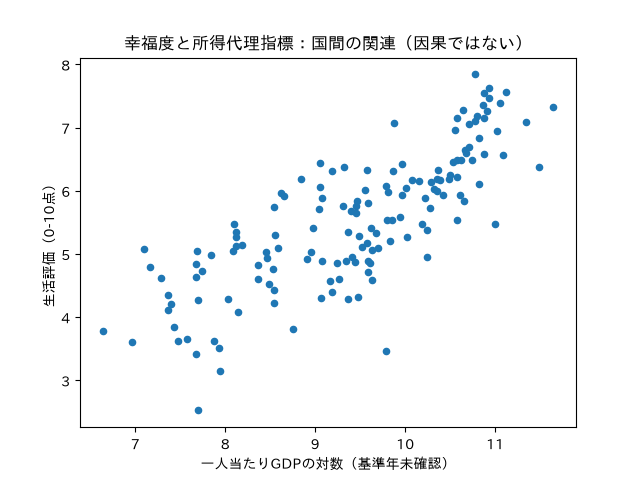

In [17]:
from IPython.display import display, Image
import matplotlib.pyplot as plt
import warnings
with execution_phase('chart_relationships'):
    with warnings.catch_warnings(record=True) as chart_warnings:
        warnings.simplefilter('always')
        scatter_png = visualization.render_chart(c,kind='scatter',x='income',y='happiness',title='幸福度と所得代理指標：国間の関連（因果ではない）',xlabel='一人当たりGDPの対数（基準年未確認）',ylabel='生活評価（0-10点）')
    scatter_output = visualization.build_image_output(scatter_png)
    scatter_glyphs = [str(w.message) for w in chart_warnings if 'Glyph' in str(w.message)]
    print('描画文字監査',scatter_glyphs)
    display(scatter_output['data'],raw=True)
    print('散布図: 2021報告/2018-2020集約の149国、国等重み。指標の単位はmanifest参照。')

描画文字監査 []
小地域は国数が少なく区間も不安定。国ブートストラップは観測国を超えた地域人口の代表性や調査国選択を保証しない。


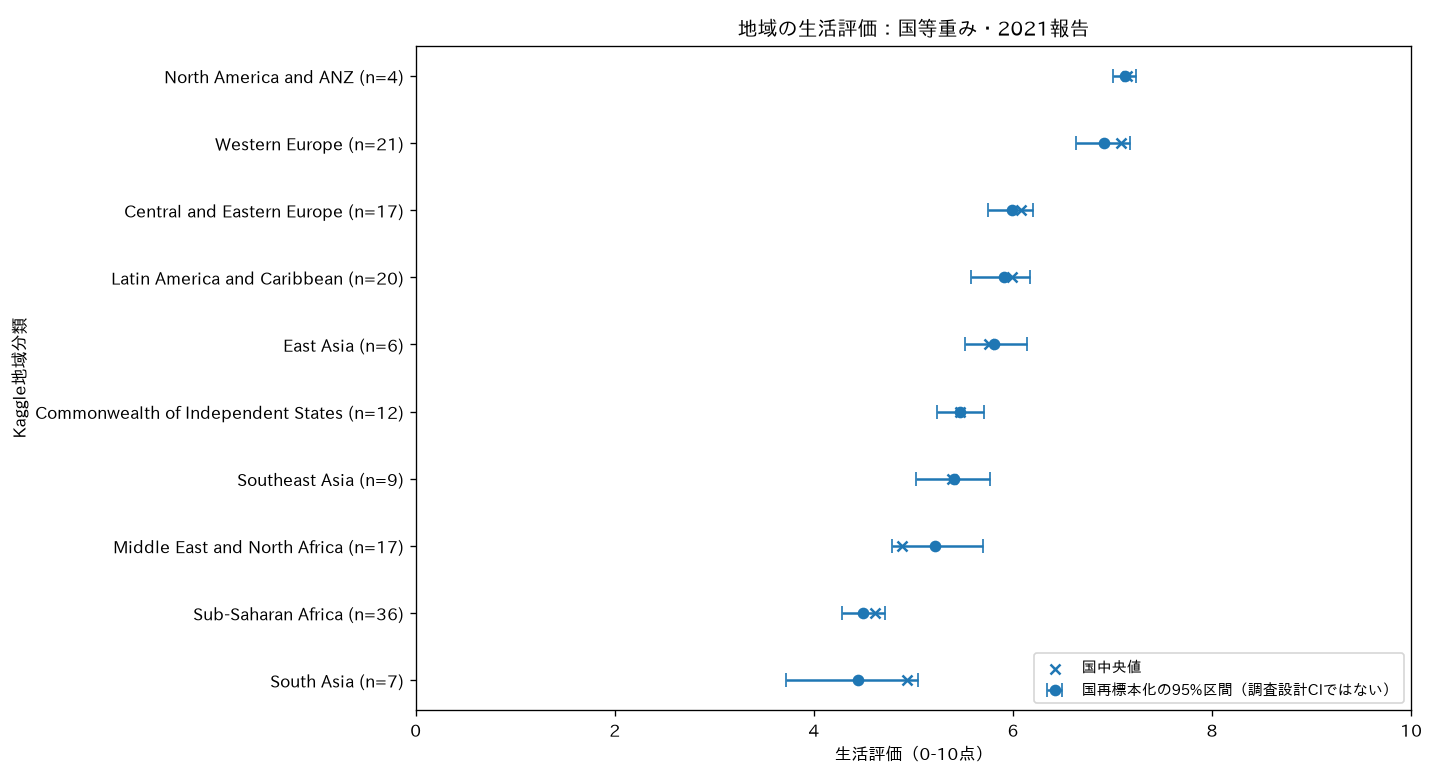

In [18]:
with execution_phase('chart_regions'):
    with warnings.catch_warnings(record=True) as region_warnings:
        warnings.simplefilter('always')
        fig,ax = plt.subplots(figsize=(12,6.5))
        ordered_regions = region_table.sort_values('mean')
        yy = np.arange(len(ordered_regions))
        ax.errorbar(ordered_regions['mean'],yy,xerr=np.vstack([ordered_regions['mean']-ordered_regions.boot_low,ordered_regions.boot_high-ordered_regions['mean']]),fmt='o',capsize=4,label='国再標本化の95%区間（調査設計CIではない）')
        ax.scatter(ordered_regions['median'], yy, marker='x',label='国中央値')
        ax.set_yticks(yy, [f'{r} (n={int(n)})' for r,n in zip(ordered_regions.index,ordered_regions.n)])
        ax.set(title='地域の生活評価：国等重み・2021報告',xlabel='生活評価（0-10点）',ylabel='Kaggle地域分類')
        ax.set_xlim(0,10)
        ax.legend(loc='lower right',fontsize=9)
        fig.tight_layout()
        buffer = io.BytesIO(); fig.savefig(buffer,format='png',dpi=120); plt.close(fig)
    region_png = buffer.getvalue()
    region_glyphs = [str(w.message) for w in region_warnings if 'Glyph' in str(w.message)]
    print('描画文字監査',region_glyphs)
    display(visualization.build_image_output(region_png)['data'],raw=True)
    print('小地域は国数が少なく区間も不安定。国ブートストラップは観測国を超えた地域人口の代表性や調査国選択を保証しない。')

描画文字監査 []
2020年は95国。観測国平均の上昇は世界全人口の幸福改善やCOVIDの効果を意味しない。


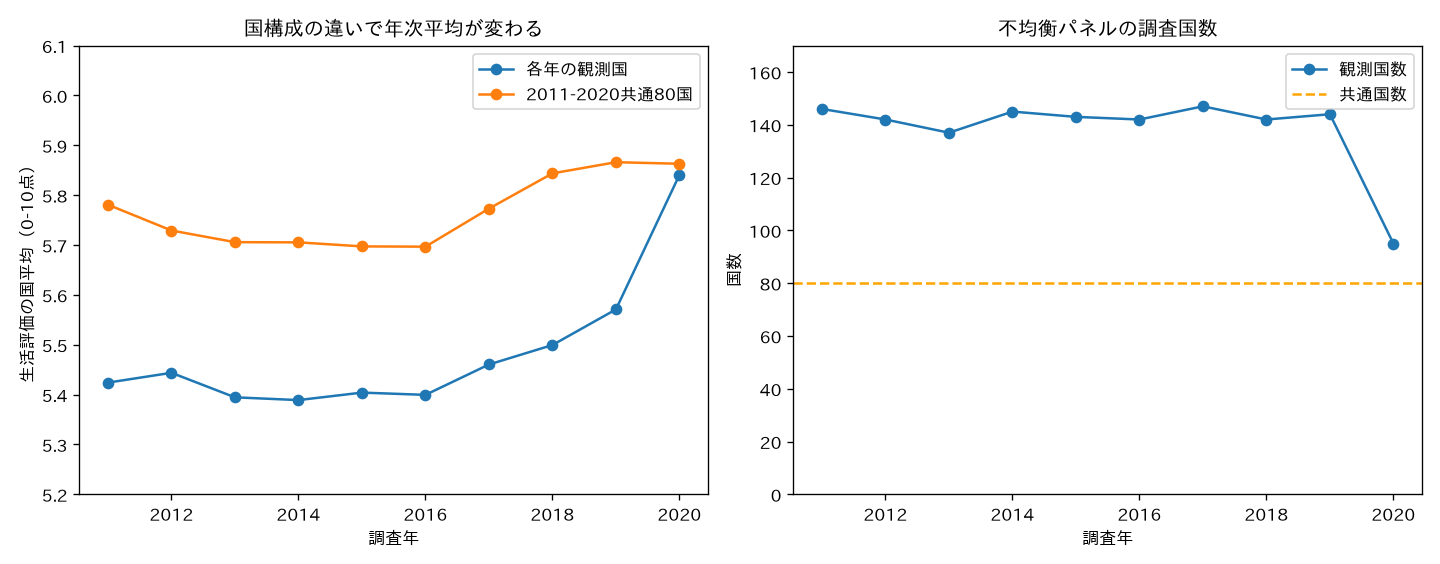

In [19]:
with execution_phase('chart_year_composition'):
    with warnings.catch_warnings(record=True) as trend_warnings:
        warnings.simplefilter('always')
        fig,axes = plt.subplots(1,2,figsize=(12,4.7))
        annual_compare[['available','common']].rename(columns={'available':'各年の観測国','common':'2011-2020共通80国'}).plot(ax=axes[0],marker='o')
        axes[0].set(title='国構成の違いで年次平均が変わる',xlabel='調査年',ylabel='生活評価の国平均（0-10点）',ylim=(5.2,6.1))
        axes[0].legend()
        annual_compare[['n_available']].rename(columns={'n_available':'観測国数'}).plot(ax=axes[1],marker='o')
        axes[1].axhline(len(common),linestyle='--',color='orange',label='共通国数')
        axes[1].set(title='不均衡パネルの調査国数',xlabel='調査年',ylabel='国数',ylim=(0,170)); axes[1].legend()
        fig.tight_layout(); buffer=io.BytesIO(); fig.savefig(buffer,format='png',dpi=120); plt.close(fig)
    trend_png = buffer.getvalue()
    trend_glyphs = [str(w.message) for w in trend_warnings if 'Glyph' in str(w.message)]
    print('描画文字監査',trend_glyphs)
    display(visualization.build_image_output(trend_png)['data'],raw=True)
    print('2020年は95国。観測国平均の上昇は世界全人口の幸福改善やCOVIDの効果を意味しない。')

描画文字監査 []
同時信頼区間ではない。国間相関・非回答・文化差を含まず、52-61位（SE1.5倍では49-63位）は公式順位の訂正ではない。


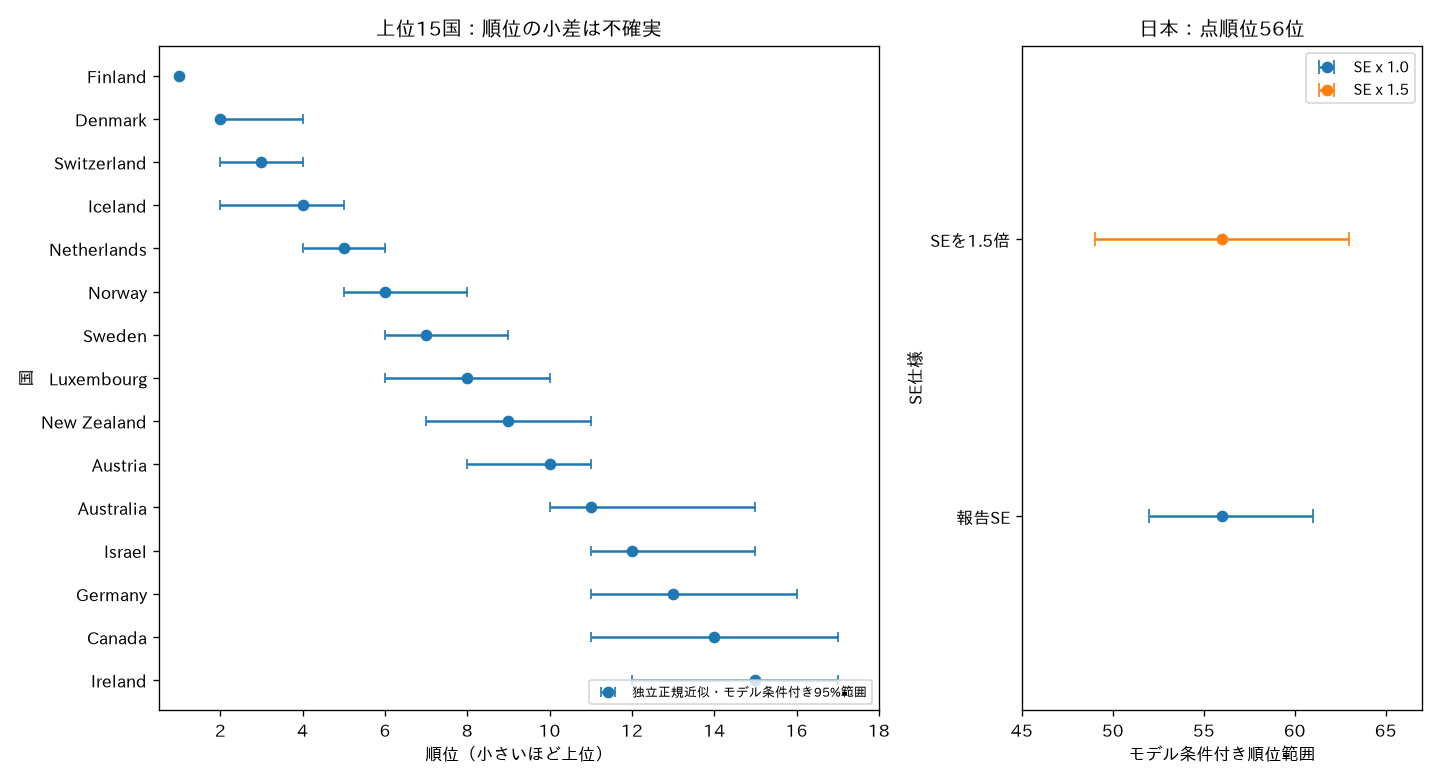

In [20]:
with execution_phase('chart_rank_intervals'):
    with warnings.catch_warnings(record=True) as rank_warnings:
        warnings.simplefilter('always')
        fig,axes = plt.subplots(1,2,figsize=(12,6.5),gridspec_kw={'width_ratios':[1.8,1]})
        top = rank_scenarios[1.0].head(15)
        yy=np.arange(len(top))
        axes[0].errorbar(top.point_rank,yy,xerr=np.vstack([top.point_rank-top.low,top.high-top.point_rank]),fmt='o',capsize=3,label='独立正規近似・モデル条件付き95%範囲')
        axes[0].set_yticks(yy,top.country); axes[0].invert_yaxis()
        axes[0].set(title='上位15国：順位の小差は不確実',xlabel='順位（小さいほど上位）',ylabel='国',xlim=(.5,18)); axes[0].legend(fontsize=8,loc='lower right')
        japan_bounds = [rank_scenarios[m].loc[rank_scenarios[m].country.eq('Japan')].iloc[0] for m in [1.0,1.5]]
        for i,row in enumerate(japan_bounds):
            axes[1].errorbar(row.point_rank,i,xerr=[[row.point_rank-row.low],[row.high-row.point_rank]],fmt='o',capsize=4,label=f'SE x {[1.0,1.5][i]}')
        axes[1].set_yticks([0,1],['報告SE','SEを1.5倍']); axes[1].set(title='日本：点順位56位',xlabel='モデル条件付き順位範囲',ylabel='SE仕様',xlim=(45,67),ylim=(-.7,1.7)); axes[1].legend(fontsize=9)
        fig.tight_layout(); buffer=io.BytesIO(); fig.savefig(buffer,format='png',dpi=120); plt.close(fig)
    rank_png=buffer.getvalue()
    rank_glyphs=[str(w.message) for w in rank_warnings if 'Glyph' in str(w.message)]
    print('描画文字監査',rank_glyphs)
    display(visualization.build_image_output(rank_png)['data'],raw=True)
    print('同時信頼区間ではない。国間相関・非回答・文化差を含まず、52-61位（SE1.5倍では49-63位）は公式順位の訂正ではない。')

In [21]:
with execution_phase('summary_and_artifacts'):
    evidence_summary = {
        'source':DATASET_SLUG, 'cross_n':len(c),'panel_rows':len(p),'panel_countries':p.country.nunique(),'panel_years':[int(p.year.min()),int(p.year.max())],
        'pearson':{x:round(float(corr_table.loc[x,'Pearson']),6) for x in predictors},
        'regions':{r:{'n':int(row['n']),'mean':round(float(row['mean']),4),'median':round(float(row['median']),4)} for r,row in region_table.iterrows()},
        'income_between':round(float(between_within.loc['income','between_country_mean']),6),
        'income_within':round(float(between_within.loc['income','within_country_demeaned']),6),
        'annual_change_available':round(float(annual_compare.loc[2020,'available']-annual_compare.loc[2011,'available']),6),
        'annual_change_common':round(float(annual_compare.loc[2020,'common']-annual_compare.loc[2011,'common']),6),
        'common_n':len(common),'paired_change_2019_2020':round(float(change.mean()),6),'paired_ci':np.round(ci_change,6).tolist(),
        'japan_rank':int(ranked.loc[ranked.country.eq('Japan'),'point_rank'].iloc[0]),
        'japan_rank_interval':rank_scenarios[1.0].loc[rank_scenarios[1.0].country.eq('Japan'),['low','high']].to_numpy()[0].tolist(),
        'japan_rank_interval_se_1_5':rank_scenarios[1.5].loc[rank_scenarios[1.5].country.eq('Japan'),['low','high']].to_numpy()[0].tolist(),
        'adjacent_holm_significant':rank_test_summary['adjacent_all_pairs_holm_significant'],
        'rank_sensitivity_stable':rank_sensitivity.stable,'rank_max_relative_deviation':rank_sensitivity.max_relative_deviation,
        'health_fe':round(float(fe_model.params['health']),6),'health_fd':round(float(fd_model.params['health']),6),
        'semantic_anomalies':len(anomalies_panel)+len(anomalies_cross),'duplicate_country_year':int(p.duplicated(['country','year']).sum()),
        'cross_correlations_stable':{k:bool(v['stable']) for k,v in sensitivity_reports.items()},
        'assumption_findings':[asdict(f) for f in analysis_assumptions.check_manifest(assumptions)]}
    display(json.dumps(evidence_summary,ensure_ascii=False,indent=2))
    print('未確認定義: GDPのPPP/基準年、寛大さの具体的変換、健康指標の補間・改訂、SEの個別調査設計。inferred項目も確定定義ではない。')
    print('因果推論の限界: 生態学的誤謬、文化的回答差、交絡（制度・教育・治安等）、逆因果、同じ調査由来の共通測定誤差、非無作為欠測、反復国年の依存性。国年FE/クラスタSEはこれらを除去しない。')
    print('適用しない機能: 個票・国年SEがないため年次順位差の検定や調査設計ブートストラップ、人口がないため人口加重地域平均、独立参照データ未提示のためdataset_validation.compare_datasets/data_quality.validate_anomalies、介入・操作変数・自然実験なしのため因果効果推定。')
    print('同一slugの2CSVは粒度・期間が異なり独立検証資料ではない。2021報告順位を2021単年の順位と解釈しない。丸め同点の連番は表示上の便宜で優劣を意味しない。')
    for item in iteration_history:
        print(json.dumps(item,ensure_ascii=False))
    lifecycle.mark_write_start(RUN_ID)
    try:
        (data_dir / 'provenance.json').write_text(json.dumps(provenance,ensure_ascii=False,indent=2),encoding='utf-8')
        (data_dir / 'data-definition-manifest.json').write_text(json.dumps(asdict(definition_manifest),ensure_ascii=False,indent=2),encoding='utf-8')
        (data_dir / 'analysis-assumptions-manifest.json').write_text(json.dumps(asdict(assumptions),ensure_ascii=False,indent=2),encoding='utf-8')
        (data_dir / 'sensitivity-results.json').write_text(json.dumps({'correlations':sensitivity_reports,'region_gap':asdict(region_ordering_sensitivity),'rank_width':asdict(rank_sensitivity)},ensure_ascii=False,indent=2),encoding='utf-8')
        (data_dir / 'iteration-history.json').write_text(json.dumps(iteration_history,ensure_ascii=False,indent=2),encoding='utf-8')
        corr_table.to_csv(data_dir / 'cross-correlations.csv')
        region_table.to_csv(data_dir / 'region-summary.csv')
        annual_compare.to_csv(data_dir / 'annual-composition.csv')
        health_check_table.to_csv(data_dir / 'health-specifications.csv',index=False)
        ranked[['country','point_rank','happiness','se','rank_low','rank_high']].to_csv(data_dir / 'rank-uncertainty.csv',index=False)
    finally:
        lifecycle.mark_write_end(RUN_ID)

未確認定義: GDPのPPP/基準年、寛大さの具体的変換、健康指標の補間・改訂、SEの個別調査設計。inferred項目も確定定義ではない。
因果推論の限界: 生態学的誤謬、文化的回答差、交絡（制度・教育・治安等）、逆因果、同じ調査由来の共通測定誤差、非無作為欠測、反復国年の依存性。国年FE/クラスタSEはこれらを除去しない。
適用しない機能: 個票・国年SEがないため年次順位差の検定や調査設計ブートストラップ、人口がないため人口加重地域平均、独立参照データ未提示のためdataset_validation.compare_datasets/data_quality.validate_anomalies、介入・操作変数・自然実験なしのため因果効果推定。
同一slugの2CSVは粒度・期間が異なり独立検証資料ではない。2021報告順位を2021単年の順位と解釈しない。丸め同点の連番は表示上の便宜で優劣を意味しない。
{"iteration": 1, "request": "国間で豊かな国ほど幸福度が高いという初回結果が、同じ国の時間変化にも当てはまるか確認してください。国平均と国平均との差の相関、国・年固定効果と国クラスタ標準誤差を比較し、相関手法・外れ値・地域除外に対する感度を調べ、因果効果とは呼ばないでください。", "reason": "国間の関連を国内の変化や因果へ外挿する危険が結論に直結", "result": "国間相関は国内相関より強い。所得・支援・健康の横断相関は8仕様でstable=True。一方、健康の固定効果係数は負で95%区間も負となり、横断の正相関と同一の推定対象ではない。", "evidence": "between_within, fe_table, sensitivity_reports", "limits": "時間変動交絡・逆因果・測定誤差、欠測非無作為。固定効果は因果識別ではない。"}
{"iteration": 2, "request": "年次平均の変化が調査対象国の入れ替わりで生じていないか、2011-2020年の共通国と2019-2020年の対応国で比較してください。地域平均・中央値・GDP等で調整した地域差を区別し、反復1で負になった健康の固定効果係数を2020年除外と連続年の一階差分で点検してください。", "reaso

'{\n  "source": "ajaypalsinghlo/world-happiness-report-2021",\n  "cross_n": 149,\n  "panel_rows": 1949,\n  "panel_countries": 166,\n  "panel_years": [\n    2005,\n    2020\n  ],\n  "pearson": {\n    "income": 0.78976,\n    "support": 0.756888,\n    "health": 0.768099,\n    "freedom": 0.607753,\n    "generosity": -0.017799,\n    "corruption": -0.42114\n  },\n  "regions": {\n    "North America and ANZ": {\n      "n": 4,\n      "mean": 7.1285,\n      "median": 7.143\n    },\n    "Western Europe": {\n      "n": 21,\n      "mean": 6.9149,\n      "median": 7.085\n    },\n    "Central and Eastern Europe": {\n      "n": 17,\n      "mean": 5.9848,\n      "median": 6.078\n    },\n    "Latin America and Caribbean": {\n      "n": 20,\n      "mean": 5.9081,\n      "median": 5.992\n    },\n    "East Asia": {\n      "n": 6,\n      "mean": 5.8103,\n      "median": 5.761\n    },\n    "Commonwealth of Independent States": {\n      "n": 12,\n      "mean": 5.467,\n      "median": 5.4715\n    },\n    "Sout

In [22]:
import copy
CONTROLLER_PATH = ROOT / 'benchmark/v020-exp-40-controller.ipynb'
controller_nb = nbformat.read(CONTROLLER_PATH,as_version=4)
selected_indices = [1,2,3,4,6,7,8,9,10,11,12,13,14,15,16,17,18]
section_titles = {
    1:'実行環境・プロジェクト・ライフサイクル登録',2:'Kaggle SDK認証と公開データ検索',3:'候補データのファイル一覧と選定',4:'CSV取得・取込み・SHA-256・国年構造',
    6:'Kaggle公開メタデータ取得',7:'公開データ説明',8:'公式報告による期間・生活評価定義の確認',9:'データ定義・分析前提manifestと意味的異常検査',
    10:'初回分析：指標の関連・地域差・順位不確実性',11:'反復依頼履歴：第1回 国間と国内変化の分離',12:'反復依頼履歴：第2回 調査国構成と健康の仕様依存',13:'反復依頼履歴：第3回 全国ペア比較と順位感度',
    14:'図1 所得代理指標と生活評価',15:'図2 地域の平均・中央値・国ブートストラップ区間',16:'図3 年次平均と調査国構成',17:'図4 順位のモデル条件付き不確実性',18:'証拠サマリー・適用範囲・分析成果保存'}
chart_meta = {
    14:{'title':'幸福度と所得代理指標：国間の関連（因果ではない）','xlabel':'一人当たりGDPの対数','ylabel':'生活評価（0-10点）','legend':'単一系列・凡例不要','missing_glyphs':scatter_glyphs},
    15:{'title':'地域の生活評価：国等重み・2021報告','xlabel':'生活評価（0-10点）','ylabel':'Kaggle地域分類','legend':'国再標本化95%区間・中央値','missing_glyphs':region_glyphs},
    16:{'title':'国構成の違いで年次平均が変わる / 不均衡パネルの調査国数','xlabel':'調査年','ylabel':'生活評価の国平均 / 国数','legend':'各年観測国・共通80国 / 観測国数・共通国数','missing_glyphs':trend_glyphs},
    17:{'title':'上位15国：順位の小差は不確実 / 日本：点順位56位','xlabel':'順位 / モデル条件付き順位範囲','ylabel':'国 / SE仕様','legend':'モデル条件付き95%範囲 / SE1.0・1.5倍','missing_glyphs':rank_glyphs}}
new_cells = [nbformat.v4.new_markdown_cell('# World Happiness：指標の関連、地域差、順位差の不確実性\n\nrun_id: `v020-exp-40`。Kaggle検索から選定した `ajaypalsinghlo/world-happiness-report-2021` の2公開CSVを使用。最新ランキングではなく、2021報告の2018-2020集約と2005-2020国年パネルを別々に分析する。全実行はJupyter MCP。国等重みの記述・関連分析であり因果推定ではない。取得失敗時のみ指定white-paperの同一CSVを確認し、推測データへ代替しない。')]
for source_index in selected_indices:
    new_cells.append(nbformat.v4.new_markdown_cell('## '+section_titles[source_index]))
    source = controller_nb.cells[source_index].source
    if source_index == 1:
        source += '\nlifecycle_events = [{"phase":"registered", "time":datetime.now(timezone.utc).isoformat(), "status":asdict(lifecycle.get_run_status(RUN_ID))}]'
    if source_index == 9:
        source = source.replace('    lifecycle.mark_execution_start(RUN_ID)\n    try:\n        yield', '    lifecycle.mark_execution_start(RUN_ID)\n    lifecycle_events.append({"phase":name,"event":"execution_start","time":datetime.now(timezone.utc).isoformat()})\n    try:\n        yield').replace('        lifecycle.mark_execution_end(RUN_ID)\n\nwith execution_phase', '        lifecycle.mark_execution_end(RUN_ID)\n        lifecycle_events.append({"phase":name,"event":"execution_end","time":datetime.now(timezone.utc).isoformat(),"status":asdict(lifecycle.get_run_status(RUN_ID))})\n\nwith execution_phase')
        source = source.replace("    print('cleaning概要', str(cleaned)[:1000])", "    print('cleaning影響', {'rows_before':cleaned.rows_before,'rows_after':cleaned.rows_after,'rows_removed':cleaned.rows_removed,'columns_affected':cleaned.columns_affected})")
    if source_index == 10:
        source = source.replace('lifecycle.register_run(RUN_ID, handle.notebook_path)\n', '')
    if source_index == 18:
        source = source.replace("    evidence_summary = {", "    assert not any([scatter_glyphs,region_glyphs,trend_glyphs,rank_glyphs]), '描画で欠落文字を検出'\n    evidence_summary = {")
    cell = nbformat.v4.new_code_cell(source)
    cell.metadata['source_controller_index'] = source_index
    if source_index in chart_meta:
        cell.metadata['chart'] = chart_meta[source_index]
    new_cells.append(cell)
def create_analysis_notebook(nb):
    if nb.cells:
        raise RuntimeError('保存先に既存セルがあり、上書きしない')
    nb.cells.extend(new_cells)
    nb.metadata.update({'language':'ja','run_id':RUN_ID,'kernelspec':{'name':'python3','display_name':'Python 3','language':'python'},'analysis_scope':'associational','execution_transport':'Jupyter MCP','initial_review_iterations':3})
lifecycle.mark_write_start(RUN_ID)
try:
    pm.enqueue_write(handle,create_analysis_notebook)
finally:
    lifecycle.mark_write_end(RUN_ID)
print('保存先',handle.notebook_path)
print('上から実行するcode cell indices', [i for i,x in enumerate(new_cells) if x.cell_type=='code'])

保存先 /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-40-world-happiness/notebooks/kaggle-v020-kaggle-exp-40-world-happiness.ipynb
上から実行するcode cell indices [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34]


In [18]:
with execution_phase('evidence_and_notebook_write'):
    executed_nb = nbformat.read(handle.notebook_path,as_version=4)
    code_cells = [x for x in executed_nb.cells if x.cell_type=='code']
    assert len(code_cells)==17 and all(x.execution_count is not None for x in code_cells)
    assert not any(o.output_type=='error' for x in code_cells for o in x.outputs)
    summary_cell = next(x for x in code_cells if 'with execution_phase(\'summary_and_artifacts\')' in x.source)
    summary_text = '\n'.join(str(o.get('data',{}).get('text/plain','')) for o in summary_cell.outputs)
    summary_result = {'output':summary_text}
    evidence_count = summary_cell.execution_count
    usage_rows = [
        ('ai_data_scientist.project_manager','resolve_project, ensure_notebook, ensure_data_dir, enqueue_write','slug検証、安定パス、データ保存先、直列Notebook書込み'),
        ('ai_data_scientist.language_router','detect_language','日本語検出'),
        ('ai_data_scientist.lifecycle','register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence','実行・書込み・取消チェック・終了状態'),
        ('ai_data_scientist.ingestion','SourceSpec, ingest','SDK取得後のCSVを上限10000行で取込み'),
        ('ai_data_scientist.cleaning','clean_dataset','重複行/完全ケースの行列影響を記録'),
        ('ai_data_scientist.eda','explore','型、欠損、要約統計'),
        ('ai_data_scientist.stats_analysis','correlation','国別Pearson相関と日本語解釈'),
        ('ai_data_scientist.visualization','render_chart, build_image_output','日本語散布図とPNG MIME出力'),
        ('ai_data_scientist.data_definition','FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields','定義のverified/inferred/unknown分離'),
        ('ai_data_scientist.analysis_assumptions','Assumption, AnalysisAssumptionManifest, check_manifest','関連分析の前提と結論重要な未確認リスク'),
        ('ai_data_scientist.data_quality','detect_anomalies','意味的値域・必須・一意性検査'),
        ('ai_data_scientist.sensitivity','SensitivityPlan, run_sensitivity','相関8仕様/指標、地域差4仕様、順位SE2仕様'),
        ('ai_data_scientist.insight_engine','extract_cited_value, record_insight','実出力の値抽出と根拠つき日本語結論'),
        ('ai_data_scientist.notebook_audit','audit_notebook(visual_audit=True)','全セル、根拠、4図の最終監査')]
    usage_md = '## 使用したJupytermindモジュール\n\n直接import・呼び出したもののみ。最後の証拠書込みはJupyter MCPの制御Notebookで行い、監査・completed記録は保存先の末尾セルで行う。間接利用を使用済みに含めない。\n\n| モジュール | 直接呼出関数・型 | 目的 |\n|---|---|---|\n' + '\n'.join('| `'+m+'` | `'+f+'` | '+why+' |' for m,f,why in usage_rows)
    usage_md += '\n\n`mcp_gateway.run_and_record` は未使用。CLIのJupyter MCPツール自体が実行transportであり、Notebook内には追加MCPClientが公開されていないため二重実行を避けた。実行済み出力はMCPが保存し、文書・根拠・metadata更新は `enqueue_write` に直列化した。`dataset_validation`、独立参照検証、z-score自動外れ値除去は未使用。国別極端値を意味的誤りとみなさない。'
    provenance_md = '## 出典・取得日・ファイル同一性\n\nKaggle参照: https://www.kaggle.com/datasets?search=world+happiness+report 。検索結果から、原指標・国年パネル・地域・標準誤差が同じslug内に揃う2021データを選定した。unsdsnの2015-2019は一部が分解寄与列であり、異なる定義を安易に連結しなかった。API取得成功のためwhite-paperへのフォールバックは未実施。\n\n' + '\n\n'.join(f'ファイル `{item["filename"]}`、owner/dataset `{item["owner_dataset_slug"]}`、取得UTC `{item["retrieved_at_utc"]}`（日本時間2026-10-02）、SHA-256 `{item["sha256"]}`。' for item in provenance)
    caveat_md = '## データ構造・前提・因果推論の限界\n\n国年パネルは166国・1949行・2005-2020年。各年の観測国数は異なり、国年キーは一意。2021報告表は149国の2018-2020集約で、2021単年ではない。237行を完全ケース解析から除外して1712行・155国を利用。補完なし、重複削除0行。地域未一致17国63行は地域別パネル比較から除外し、未一致を推測分類しない。地域分類は2021時点固定で国境変更を復元しない。\n\n意味的異常検査は0件だが、適切な値域の内側にある測定誤りを否定しない。健康の補間・改訂、GDPのPPP基準年、寛大さの変換、各国SEの調査設計は未確認。`unresolved_fields()`がunknownだけを返すためinferredも別途明示した。\n\n前提manifestの警告は3件：測定の年次比較可能性、完全ケース/国選択の歪みが小さいこと、順位計算の独立正規近似と報告SEの妥当性はassumedのまま。感度分析でこれらをverifiedへ格上げしない。人口加重・調査設計再標本化・年次順位差の検定・独立データ検証・因果推定は必要資料がなく非適用。同一slugの2CSVは独立検証資料ではない。\n\n交絡（制度・教育・治安等）、逆因果、共通調査の測定誤差、文化差、非回答・非無作為欠測、生態学的誤謬が残る。国年固定効果・国クラスタSE・一階差分は関連の仕様比較であり、介入効果や「健康改善が幸福を低下させる」といった因果結論を支持しない。地域の国ブートストラップ区間は国の異質性の感度であって、地域人口に対する調査設計の信頼区間ではない。'
    history_md = '## 反復依頼履歴\n\n初回結果を読み直し、結論を変え得る未解決点に絞って3回実行した。以下の依頼文は生成時の原文をそのまま保持する。\n'
    iteration_evidence = {1:(20,'between_within・fe_table・sensitivity_reports'),2:(22,'annual_compare・health_check_table・region_table'),3:(24,'rank_test_summary・rank_scenarios・rank_sensitivity')}
    for item in iteration_history:
        idx,variables = iteration_evidence[item['iteration']]
        actual = executed_nb.cells[idx]
        history_md += f'\n### 第{item["iteration"]}回\n\n**依頼原文**\n\n{item["request"]}\n\n**選定理由**：{item["reason"]}\n\n**結果**：{item["result"]}\n\n**証拠**：セルindex={idx}、id=`{actual.id}`、execution_count={actual.execution_count}、{variables}。\n\n**残る限界**：{item["limits"]}\n'
    history_md += '\n**反復2の実測補足**：2011-2020変化は全観測国0.416518点、共通80国0.082100点。2019-2020対応93国は-0.008129点、国ブートストラップ95%区間[-0.094860, 0.076344]。健康FE係数-0.03795に対し連続年一階差分は0.00234、95%区間[-0.03849, 0.04318]であり仕様依存。\n\n**反復3の実測補足**：隣接148組のnominal有意6組に対し、全国11026ペアHolm補正では2組。順位幅の中央値は9から13（44.44%拡大）でstable=False。\n\n**停止理由**：最大3回に到達。残る識別・調査設計・文化的測定差の限界は同じ集計CSVだけで解消できず、追加の同種仕様の価値は低い。'
    improvements_md = '## Jupytermind改善候補\n\nなし。今回、Jupytermind固有の不具合を再現していない。取得メタデータの不足やデータの識別限界をライブラリの欠陥と混同しない。\n\n切り分け記録：初期制御Notebookで存在しないKaggle SDK `dataset_view` を参照したAttributeErrorは呼出側/SDK仕様の問題で、削除後にCSV取得成功。`EDAReport`をdictのように扱ったTypeErrorも呼出側の型理解の誤りで、`asdict`に修正して復旧。最初のMCP作成で親フォルダ不在はMCP側のパス前提で、`ensure_notebook`による作成で回避。保存先の最終再実行にはこれらのエラーはない。Copilot CLI・Kaggle API・ベンチマークランナー固有の問題をJupytermind候補へ分類しない。関係ログ：`benchmark/v020-exp-40-controller.ipynb`の初期取得セル・manifestセル（修正履歴は本文）、本Notebookの取込み/品質セル。分類・再現条件・期待/実際・影響・回避策を記録すべきJupytermind候補は発見されなかった。'
    def write_documentation(nb):
        nb.cells.extend(nbformat.v4.new_markdown_cell(text) for text in [provenance_md,usage_md,caveat_md,history_md,improvements_md,'## 実出力に基づく最終結論'])
        nb.metadata['provenance'] = provenance
        nb.metadata['final_reexecution'] = {'kernel_restarted':True,'transport':'Jupyter MCP execute_cell','code_cell_order':[x.id for x in code_cells],'execution_counts':[x.execution_count for x in code_cells],'all_code_executed':True}
        nb.metadata['iteration_history'] = iteration_history
        nb.metadata['lifecycle_events'] = lifecycle_events
    lifecycle.mark_write_start(RUN_ID)
    try:
        pm.enqueue_write(handle,write_documentation)
        claims = [
            ('1949',r'"panel_rows": (\d+)',f'**構造**：2005-2020年の国年データは{evidence_summary["panel_rows"]}行・{evidence_summary["panel_countries"]}国。2021報告の149国集約表と分離した。'),
            ('corr',r'"income": ([0-9.]+)',f'**指標との関連**：国別幸福度とGDP対数のPearson相関は{evidence_summary["pearson"]["income"]:.4f}、社会的支援{evidence_summary["pearson"]["support"]:.4f}、健康{evidence_summary["pearson"]["health"]:.4f}。自由は0.6078、腐敗認識は-0.4211、寛大さは-0.0178。国平均の関連で、個人の所得効果ではない。'),
            ('region',r'"mean": (7\.1285)', '**地域差**：北米・ANZ（4国）の国平均7.1285、西欧（21国）6.9149に対し、SSA（36国）4.4945、南アジア（7国）4.4419。南アジアの中央値は4.934でSSAの4.616より高く、細かい地域順位は要約手法で変わる。GDP等の粗回帰調整後には中南米の残差+0.246、東アジア-0.240となり、粗平均差と調整後差は別物。地域の因果効果ではない。'),
            ('within',r'"income_within": ([0-9.]+)', '**国内変化**：所得の国平均間相関0.8370に対し、国平均との差を用いた国内相関は0.2930。豊かな国ほど幸福という結果を、所得上昇の介入効果へ外挿しない。健康は横断では正だが固定効果では負、一階差分ではほぼゼロであり、効果の断定は不適切。'),
            ('annual',r'"annual_change_common": ([0-9.]+)', '**年次構成**：2011-2020の観測国平均上昇0.416518点に対し、共通80国では0.082100点。2020年の観測国は95へ減少している。2019-2020対応93国では平均差-0.008129点で国再標本化区間がゼロを含む。世界人口の改善やCOVIDの因果効果を主張しない。'),
            ('rank',r'"adjacent_holm_significant": (\d+)', '**順位差の不確実性**：全国11026ペアのHolm補正後に識別できる隣接順位差は148組中2組だけ。日本の点順位56位に対し独立正規近似による条件付き95%範囲52-61位、SE1.5倍で49-63位。これは公式順位の訂正でも同時信頼区間でもなく、非回答・文化差・国間相関を含まない。'),
            ('sensitivity',r'"rank_max_relative_deviation": ([0-9.]+)', '**感度判定**：横断の所得・支援・健康相関は各8仕様・相対偏差20%閾値でstable=True（最大偏差11.99%、5.81%、8.44%）。西欧-SSAの最近年の関連差も4仕様でstable=True、最大5.99%。順位区間幅はSE1.5倍で中央値9から13へ44.44%拡大しstable=False。安定は選んだ仕様内に限られ、因果識別や欠測の無偏りを保証しない。')]
        for label,pattern,text in claims:
            cited = insight_engine.extract_cited_value(summary_result,pattern)
            insight_engine.record_insight(handle,text,evidence_count,cited,'associational' if label in ['corr','within'] else 'descriptive',language='ja')
    finally:
        lifecycle.mark_write_end(RUN_ID)
    print('根拠付き結論7件を記録。summary execution_count=',evidence_count)
    preliminary_audit = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    print('保存済みNotebook監査', {'ok':preliminary_audit.ok,'executed':preliminary_audit.executed_code_cell_count,'findings':[asdict(f) for f in preliminary_audit.findings],'visual_findings':[asdict(f) for f in preliminary_audit.visual_findings]})
    assert preliminary_audit.ok

根拠付き結論7件を記録。summary execution_count= 17
保存済みNotebook監査 {'ok': True, 'executed': 17, 'findings': [], 'visual_findings': []}


In [19]:
FINAL_AUDIT_SOURCE = '''with execution_phase('notebook_final_audit'):
    final_audit = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
    display(json.dumps({'ok':final_audit.ok, **asdict(final_audit)},ensure_ascii=False,indent=2))
    if not final_audit.ok:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Notebook監査失敗。未実行・エラー・古い根拠・図の指摘を解決するまでcompletedにしない。')
lifecycle.mark_completed(RUN_ID)
final_lifecycle = lifecycle.wait_for_quiescence(RUN_ID, timeout_s=5)
assert final_lifecycle.state == 'completed'
assert final_lifecycle.active_cell_executions == 0 and final_lifecycle.pending_notebook_writes == 0 and final_lifecycle.locks_held == 0
display(json.dumps(asdict(final_lifecycle),ensure_ascii=False,indent=2))
print('全コードの上からの再実行、4図visual_audit=True、根拠監査、completedを確認。末尾自己監査セルの出力保存後にも制御Notebookから再監査しmetadataへ記録する。')'''
lifecycle.mark_write_start(RUN_ID)
try:
    def append_final_audit(nb):
        nb.cells.append(nbformat.v4.new_markdown_cell('## 最終再実行・Notebook監査・ライフサイクル\n\nカーネルを再起動し、全分析コード17セルを上からJupyter MCPで再実行した後、以下の監査コードを最後に実行する。自己監査中の末尾セルを除外するwarningは仕様であり、出力保存後の外部再監査では全18セルを検査する。最終結果はNotebook metadataと末尾の監査記録にも保持する。根拠は実際のexecution_countと実出力に紐付くため、部分再実行で古くなれば監査を失敗させる。'))
        final_cell = nbformat.v4.new_code_cell(FINAL_AUDIT_SOURCE)
        final_cell.metadata['role'] = 'final_audit'
        nb.cells.append(final_cell)
        for cell,glyphs in zip([x for x in nb.cells if x.metadata.get('chart')],[scatter_glyphs,region_glyphs,trend_glyphs,rank_glyphs]):
            cell.metadata.chart['missing_glyphs'] = glyphs
    pm.enqueue_write(handle,append_final_audit)
finally:
    lifecycle.mark_write_end(RUN_ID)
print('末尾監査セル',len(nbformat.read(handle.notebook_path,as_version=4).cells)-1)

末尾監査セル 49


In [21]:
postsave_audit = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
assert postsave_audit.ok and postsave_audit.executed_code_cell_count==18
assert not postsave_audit.findings and not postsave_audit.visual_findings
postsave_nb = nbformat.read(handle.notebook_path,as_version=4)
replay_cells = [x for x in postsave_nb.cells if x.cell_type=='code']
assert all(a.execution_count < b.execution_count for a,b in zip(replay_cells,replay_cells[1:]))
for item in provenance:
    assert hashlib.sha256((data_dir/item['filename']).read_bytes()).hexdigest()==item['sha256']
lifecycle_events.append({'phase':'postsave_audit','event':'verified','time':datetime.now(timezone.utc).isoformat(),'code_cells':18,'visual_audit':True})
lifecycle.mark_write_start(RUN_ID)
try:
    def save_final_records(nb):
        nb.metadata['notebook_audit'] = {'ok':postsave_audit.ok,**asdict(postsave_audit),'visual_audit':True,'audited_at_utc':datetime.now(timezone.utc).isoformat()}
        nb.metadata['final_reexecution'].update({'code_cell_order':[x.id for x in replay_cells],'execution_counts':[x.execution_count for x in replay_cells],'all_code_executed':True,'code_cells':18,'strictly_increasing_counts':True})
        nb.metadata['lifecycle_events'] = lifecycle_events
        nb.cells.append(nbformat.v4.new_markdown_cell('## 出力保存後の最終監査記録\n\n`notebook_audit.audit_notebook(..., visual_audit=True)`：ok=True、nbformat_valid=True、18/18コードセル実行済み、未実行0、エラー0、図4、根拠付き結論7、findings=[]、visual_findings=[]。全コードの実execution_countはNotebook順に増加し、カーネル再起動後に上から実行した。2CSVの保存内容のSHA-256一致を再確認。\n\nrun_id=`v020-exp-40`、ライフサイクル=`completed`、active_cell_executions=0、pending_notebook_writes=0、locks_held=0。書込み終了後の状態スナップショットはmetadata.lifecycleとdata/lifecycle-final.jsonにも記録する。APIトークンや認証ファイルの内容は表示・保存していない。'))
    pm.enqueue_write(handle,save_final_records)
finally:
    lifecycle.mark_write_end(RUN_ID)
final_state = lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
assert final_state.state=='completed' and final_state.active_cell_executions==0 and final_state.pending_notebook_writes==0 and final_state.locks_held==0
lifecycle.mark_write_start(RUN_ID)
try:
    pm.enqueue_write(handle,lambda nb: nb.metadata.update({'lifecycle':asdict(final_state)}))
    (data_dir/'lifecycle-final.json').write_text(json.dumps(asdict(final_state),ensure_ascii=False,indent=2),encoding='utf-8')
    (data_dir/'notebook-audit.json').write_text(json.dumps({'ok':postsave_audit.ok,**asdict(postsave_audit),'visual_audit':True},ensure_ascii=False,indent=2),encoding='utf-8')
finally:
    lifecycle.mark_write_end(RUN_ID)
verified_audit = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
verified_state = lifecycle.get_run_status(RUN_ID)
assert verified_audit.ok and not verified_audit.findings and not verified_audit.visual_findings
assert verified_state == final_state
print(json.dumps({'notebook':str(handle.notebook_path),'audit_ok':verified_audit.ok,'executed_code_cells':verified_audit.executed_code_cell_count,'charts':len(verified_audit.chart_cell_indices),'insights':verified_audit.insight_cell_count,'lifecycle':asdict(verified_state),'size_bytes':handle.notebook_path.stat().st_size},ensure_ascii=False,indent=2))

{
  "notebook": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-40-world-happiness/notebooks/kaggle-v020-kaggle-exp-40-world-happiness.ipynb",
  "audit_ok": true,
  "executed_code_cells": 18,
  "charts": 4,
  "insights": 7,
  "lifecycle": {
    "run_id": "v020-exp-40",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-40-world-happiness/notebooks/kaggle-v020-kaggle-exp-40-world-happiness.ipynb",
    "reason": null
  },
  "size_bytes": 547310
}


In [1]:
from pathlib import Path
import sys, os, json, nbformat, hashlib, re, copy
from dataclasses import asdict
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
from ai_data_scientist import project_manager as pm, lifecycle, notebook_audit, data_definition, insight_engine, language_router
handle = pm.resolve_project('kaggle-v020-kaggle-exp-40-world-happiness')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
FOLLOWUP_RUN_ID = 'v020-exp-40-followup'
lifecycle.register_run(FOLLOWUP_RUN_ID, handle.notebook_path)
original_nb = nbformat.read(handle.notebook_path, as_version=4)
original_cells = [{'id':cell.id,'cell_type':cell.cell_type,'source':cell.source} for cell in original_nb.cells]
(data_dir / 'followup-original-cells.json').write_text(json.dumps(original_cells, ensure_ascii=False, indent=2), encoding='utf-8')
print('language', language_router.detect_language('初回分析と反復依頼を再評価してください'))
print('既存セル',[(i, cell.id,cell.cell_type,cell.get('execution_count')) for i,cell in enumerate(original_nb.cells)])
print('chart metadata',[(i,cell.metadata.get('chart')) for i,cell in enumerate(original_nb.cells) if 'chart' in cell.metadata])
print('初期監査',asdict(notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)))
print('manifest keys',list(original_nb.metadata))
print('保存済み公式出典抜粋', [out.get('text',out.get('data',{}).get('text/plain','')) for out in original_nb.cells[14].outputs])
print('順位セル出力', [out.get('text',out.get('data',{}).get('text/plain','')) for out in original_nb.cells[24].outputs])

language ja
既存セル [(0, 'cf9b44ae', 'markdown', None), (1, '9001c845', 'markdown', None), (2, '905f525d', 'code', 1), (3, 'cbb6f8de', 'markdown', None), (4, '136154fa', 'code', 2), (5, '51bf233a', 'markdown', None), (6, '926d9edf', 'code', 3), (7, '5baa0050', 'markdown', None), (8, '46fd0897', 'code', 4), (9, 'f1c9c0aa', 'markdown', None), (10, 'cfcfd0c4', 'code', 5), (11, 'ba0821f0', 'markdown', None), (12, 'e6a75575', 'code', 6), (13, 'ff9b3518', 'markdown', None), (14, '0a47e89a', 'code', 7), (15, '94973d53', 'markdown', None), (16, 'a8fc2036', 'code', 8), (17, 'b5e12b8a', 'markdown', None), (18, '3111c4d7', 'code', 9), (19, 'a90748bc', 'markdown', None), (20, '183bd230', 'code', 10), (21, '27bc4d6a', 'markdown', None), (22, '20258cd3', 'code', 11), (23, '962611a1', 'markdown', None), (24, '06cfaa92', 'code', 12), (25, '0d53ecc3', 'markdown', None), (26, 'ad02a1df', 'code', 13), (27, 'f2a1f10e', 'markdown', None), (28, '01553353', 'code', 14), (29, 'b30e169b', 'markdown', None), (30, 